<a href="https://colab.research.google.com/github/shafiqul-cyber/Skill_Morph_Practice_from_Instrictor-/blob/Skill_Morph/Assignment_6_Introduction_to_Machine_Learning_Skill_Morph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 6**

#Question 1: Find the Best Tree Depth

#Task: Test depths 5, 6, 7, 8,9 and find highest accuracy,
#optional: input features 10.


#Question 2: Calculate All Metrics

#Task: Use best depth to calculate precision, recall, F1-score


#Question 3: Test on New Patients(y_test)


#Question 4: Analyze Confusion Matrix

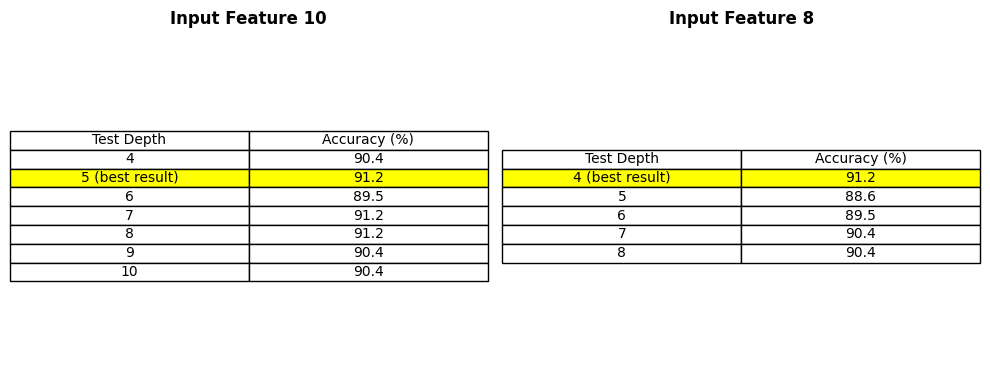

In [138]:
import matplotlib.pyplot as plt
import pandas as pd

# Data for left table (Input Feature = 10)
data_left = {
    "Test Depth": [4, "5 (best result)", 6, 7, 8, 9, 10],
    "Accuracy (%)": [90.4, 91.2, 89.5, 91.2, 91.2, 90.4, 90.4]
}
df_left = pd.DataFrame(data_left)

# Data for right table (Input Feature = 8)
data_right = {
    "Test Depth": ["4 (best result)", 5, 6, 7, 8],
    "Accuracy (%)": [91.2, 88.6, 89.5, 90.4, 90.4]
}
df_right = pd.DataFrame(data_right)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left table
axes[0].axis('off')
tbl1 = axes[0].table(cellText=df_left.values,
                     colLabels=df_left.columns,
                     cellLoc='center',
                     loc='center')

# Highlight the best row (row index 1 in df_left)
tbl1[(1+1, 0)].set_facecolor("yellow")  # +1 because row 0 is header
tbl1[(1+1, 1)].set_facecolor("yellow")

axes[0].set_title("Input Feature 10", fontsize=12, fontweight='bold')

# Right table
axes[1].axis('off')
tbl2 = axes[1].table(cellText=df_right.values,
                     colLabels=df_right.columns,
                     cellLoc='center',
                     loc='center')

# Highlight the best row (row index 0 in df_right)
tbl2[(0+1, 0)].set_facecolor("yellow")
tbl2[(0+1, 1)].set_facecolor("yellow")

axes[1].set_title("Input Feature 8", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


In [1]:
print("Welcome to Cancer Detection with Skill Morph!")
print("We will build a Skill Moprh Doctor to detect breast cancer!")

Welcome to Cancer Detection with Skill Morph!
We will build a Skill Moprh Doctor to detect breast cancer!


# **Introduction**

In [2]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, auc
)
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset

In [3]:
print("Reading the real cancer dataset...")
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

Reading the real cancer dataset...
Mounted at /content/drive


In [4]:
data = pd.read_csv('/content/drive/MyDrive/datasets/class_6/Breast_Cancer_Wisconsin_Dataset.csv')

In [5]:
print(f"Dataset loaded! We have data from {len(data)} real patients")
print(f"Each patient has {len(data.columns)-2} medical measurements")

Dataset loaded! We have data from 569 real patients
Each patient has 31 medical measurements


In [6]:
# Show first few patients
print("\nFirst 5 patients in our dataset:")
print(data[['id', 'diagnosis', 'radius_mean', 'texture_mean', 'area_mean']].head())


First 5 patients in our dataset:
         id diagnosis  radius_mean  texture_mean  area_mean
0    842302         M        17.99         10.38     1001.0
1    842517         M        20.57         17.77     1326.0
2  84300903         M        19.69         21.25     1203.0
3  84348301         M        11.42         20.38      386.1
4  84358402         M        20.29         14.34     1297.0


In [9]:
# Understand diagnosis column
print(f"\nUnderstanding Diagnosis:")
diagnosis_counts = data['diagnosis'].value_counts()


Understanding Diagnosis:


In [ ]:
print(diagnosis_counts)

diagnosis
B    357
M    212
Name: count, dtype: int64


In [ ]:
print(f"M (Malignant = Dangerous Cancer):  {diagnosis_counts['M']} patients")
print(f"B (Benign = Harmless Cancer):      {diagnosis_counts['B']} patients")
print(f"Total patients:                    {len(data)} patients")

M (Malignant = Dangerous Cancer):  212 patients
B (Benign = Harmless Cancer):      357 patients
Total patients:                    569 patients


# **Prepare Data**

In [11]:
print("Computers only understand numbers, not letters!")
print("Converting M → 1 (Malignant Cancer) and B → 0 (Benign Cancer)")

# Convert diagnosis to numbers
data['diagnosis_numeric'] = data['diagnosis'].map({'M': 1, 'B': 0})
print("Conversion completed!")

Computers only understand numbers, not letters!
Converting M → 1 (Malignant Cancer) and B → 0 (Benign Cancer)
Conversion completed!


In [48]:
data.columns.tolist()

['id',
 'diagnosis',
 'radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'perimeter_se',
 'area_se',
 'smoothness_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'symmetry_se',
 'fractal_dimension_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst',
 'Unnamed: 32',
 'diagnosis_numeric']

In [122]:
# Select only the most important features (make it simple!) (Features)
important_features = [
    'radius_mean',      # Size of tumor
    'texture_mean',     # Surface texture
    'perimeter_mean',
    'area_mean',        # Area of tumor
    'compactness_se',
    'concavity_se',
    'concave points_se',
    'fractal_dimension_se',
    'smoothness_mean',  # How smooth the surface is
    'compactness_mean', # How compact the tumor is
]

In [123]:
# Create simple dataset
X = data[important_features]  # Patient measurements
y = data['diagnosis_numeric']  # Malignant (1) or Benign (0)

print(f"\nData prepared:")
print(f"X (measurements): {X.shape}")
print(f"y (diagnosis): {y.shape}")


Data prepared:
X (measurements): (569, 10)
y (diagnosis): (569,)


# **Train and Test Split**

In [124]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=20
)

print(f"Training: {len(X_train)} patients (computer will learn from these)")
print(f"Testing:  {len(X_test)} patients (computer will be tested on these)")

Training: 455 patients (computer will learn from these)
Testing:  114 patients (computer will be tested on these)


In [125]:
# Show some training examples
print(f"\n Training Examples (Computer learns from these):")
print(X_train.head())


 Training Examples (Computer learns from these):
     radius_mean  texture_mean  perimeter_mean  area_mean  compactness_se  \
412        9.397         21.68           59.75      268.8        0.026740   
461       27.420         26.27          186.90     2501.0        0.053740   
532       13.680         16.33           87.76      575.5        0.007228   
495       14.870         20.21           96.12      680.9        0.013710   
13        15.850         23.95          103.70      782.7        0.031260   

     concavity_se  concave points_se  fractal_dimension_se  smoothness_mean  \
412      0.037350           0.005128              0.004583          0.07969   
461      0.080550           0.025980              0.004558          0.10840   
532      0.007078           0.005077              0.001697          0.09277   
495      0.021530           0.011830              0.001812          0.09587   
13       0.050510           0.019920              0.003002          0.08401   

     compact

In [127]:
# Show some test examples
print(f"\n Training Examples (Computer learns from these):")
print(X_test.head())


 Training Examples (Computer learns from these):
     radius_mean  texture_mean  perimeter_mean  area_mean  compactness_se  \
269        10.71         20.39           69.50      344.9        0.047850   
263        15.61         19.38          100.00      758.6        0.009105   
30         18.63         25.11          124.80     1088.0        0.033740   
452        12.00         28.23           76.77      442.5        0.025890   
214        14.19         23.81           92.87      610.7        0.037100   

     concavity_se  concave points_se  fractal_dimension_se  smoothness_mean  \
269       0.07339           0.017450              0.007610          0.10820   
263       0.01311           0.005174              0.001345          0.07840   
30        0.05196           0.011580              0.004560          0.10640   
452       0.02941           0.009166              0.004302          0.08437   
214       0.03688           0.016270              0.004768          0.09463   

     compact

# **Train with Decision Tree**

In [128]:
# Create our Skill Morph model
skillmorph_doctor = DecisionTreeClassifier(
    max_depth=8,  # Keep it simple - not too complex
    random_state=20
)

In [129]:
print("Teaching Skill Morph doctor with training data...")
# Train the model
skillmorph_doctor.fit(X_train, y_train)
print("Skill Morph doctor training completed!")

Teaching Skill Morph doctor with training data...
Skill Morph doctor training completed!


In [130]:
print("\nSkill Morph Doctor has learned to recognize patterns like:")
print("- If tumor radius > 15mm AND texture rough → High malignant cancer risk")
print("- If tumor area small AND smooth → Likely benign cancer")



Skill Morph Doctor has learned to recognize patterns like:
- If tumor radius > 15mm AND texture rough → High malignant cancer risk
- If tumor area small AND smooth → Likely benign cancer


# **Test our Skill Morph Doctor**

In [131]:
print("Now let's see how good our Skill Morph doctor is...")
print("Testing on patients it has NEVER seen before!")

# Make predictions
predictions = skillmorph_doctor.predict(X_test)
prediction_probabilities = skillmorph_doctor.predict_proba(X_test)[:, 1]  # Probability of malignant cancer (class 1)
print("Skill Morph doctor made predictions for all test patients!")
print(f"Note: We also got probability scores (confidence levels) for each prediction!")

Now let's see how good our Skill Morph doctor is...
Testing on patients it has NEVER seen before!
Skill Morph doctor made predictions for all test patients!
Note: We also got probability scores (confidence levels) for each prediction!


In [132]:
# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"\nSkill Morph Doctor Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")


Skill Morph Doctor Accuracy: 0.912 (91.2%)


In [133]:
if accuracy > 0.95:
    print("EXCELLENT! Our Skill Morph doctor is very accurate!")
elif accuracy > 0.90:
    print("GOOD! Our Skill Morph doctor performs well!")
elif accuracy > 0.80:
    print("OK! Our Skill Morph doctor is decent!")
else:
    print("Needs improvement...")

GOOD! Our Skill Morph doctor performs well!


In [134]:
# Show some predictions vs reality with confidence
print(f"\nLet's check some predictions with confidence:")
print("Patient | Actual      | Skill Morph Predicted | Confidence | Correct?")
print("-" * 70)
for i in range(10):
    actual = "Malignant" if y_test.iloc[i] == 1 else "Benign"
    predicted = "Malignant" if predictions[i] == 1 else "Benign"
    confidence = prediction_probabilities[i] * 100 if predictions[i] == 1 else (1 - prediction_probabilities[i]) * 100
    correct = "✅" if y_test.iloc[i] == predictions[i] else "❌"
    print(f"{i+1:7} | {actual:11} | {predicted:17} | {confidence:8.1f}%  | {correct}")


Let's check some predictions with confidence:
Patient | Actual      | Skill Morph Predicted | Confidence | Correct?
----------------------------------------------------------------------
      1 | Benign      | Benign            |    100.0%  | ✅
      2 | Malignant   | Malignant         |    100.0%  | ✅
      3 | Malignant   | Malignant         |    100.0%  | ✅
      4 | Benign      | Benign            |    100.0%  | ✅
      5 | Malignant   | Benign            |    100.0%  | ❌
      6 | Malignant   | Malignant         |    100.0%  | ✅
      7 | Malignant   | Malignant         |    100.0%  | ✅
      8 | Benign      | Benign            |    100.0%  | ✅
      9 | Benign      | Benign            |    100.0%  | ✅
     10 | Malignant   | Malignant         |    100.0%  | ✅


# Confusion Matrix

Confusion Matrix (Mistake Analysis):
[[59  7]
 [ 3 45]]

How to read Confusion Matrix:

                 Skill Morph Predicted
              Benign   Malignant
Real Benign     59        7   ← 7 False Alarms (predicted malignant but was benign)
Real Malignant  3        45   ← 3 Missed Malignant (predicted benign but was malignant) ⚠️

✅ Correct Predictions: 104
❌ Wrong Predictions: 10

⚠️ DANGER: Missing malignant cancer (3 cases) is more dangerous than false alarms (7 cases)



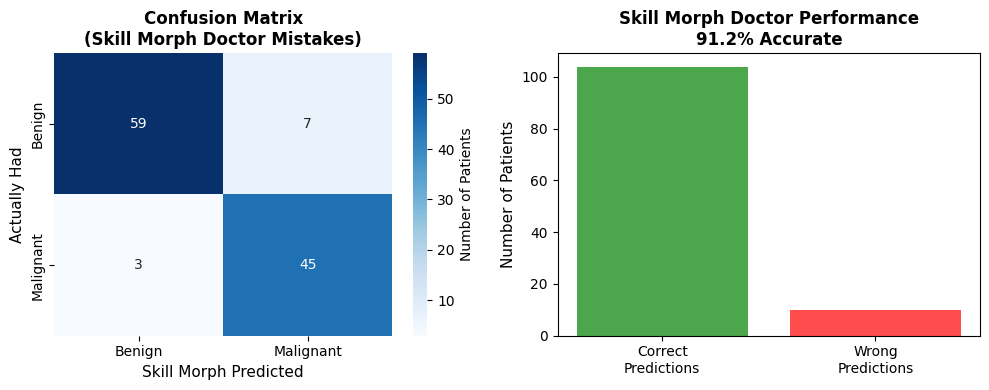

In [135]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix (Mistake Analysis):")
print(cm)

print("\nHow to read Confusion Matrix:")
print(f"""
                 Skill Morph Predicted
              Benign   Malignant
Real Benign     {cm[0,0]}        {cm[0,1]}   ← {cm[0,1]} False Alarms (predicted malignant but was benign)
Real Malignant  {cm[1,0]}        {cm[1,1]}   ← {cm[1,0]} Missed Malignant (predicted benign but was malignant) ⚠️

✅ Correct Predictions: {cm[0,0] + cm[1,1]}
❌ Wrong Predictions: {cm[0,1] + cm[1,0]}

⚠️ DANGER: Missing malignant cancer ({cm[1,0]} cases) is more dangerous than false alarms ({cm[0,1]} cases)
""")

# Create beautiful confusion matrix plot
plt.figure(figsize=(10, 4))

# Confusion Matrix Plot
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'],
            cbar_kws={'label': 'Number of Patients'})
plt.title('Confusion Matrix\n(Skill Morph Doctor Mistakes)', fontweight='bold', fontsize=12)
plt.xlabel('Skill Morph Predicted', fontsize=11)
plt.ylabel('Actually Had', fontsize=11)

# Accuracy visualization
plt.subplot(1, 2, 2)
categories = ['Correct\nPredictions', 'Wrong\nPredictions']
values = [cm[0,0] + cm[1,1], cm[0,1] + cm[1,0]]
colors = ['green', 'red']
plt.bar(categories, values, color=colors, alpha=0.7)
plt.title(f'Skill Morph Doctor Performance\n{accuracy*100:.1f}% Accurate', fontweight='bold', fontsize=12)
plt.ylabel('Number of Patients', fontsize=11)

plt.tight_layout()
plt.show()

# **Detailed Performance**

 MEDICAL EVALUATION METRICS EXPLAINED:

Think of Skill Morph as a detective looking for malignant cancer:

1️⃣ ACCURACY = Overall correctness
   → How many total cases did we get right?

2️⃣ PRECISION = When we say "MALIGNANT", how often are we right?
   → Of all "malignant" predictions, how many were actually malignant?
   → High precision = Few false alarms

3️⃣ RECALL  = Of all actual malignant cancer cases, how many did we catch?
   → Did we miss any malignant cancer patients?
   → High recall = We don't miss malignant cancer cases

4️⃣ F1-SCORE = Balance between Precision and Recall
   → Perfect balance between avoiding false alarms and catching all malignant cancers



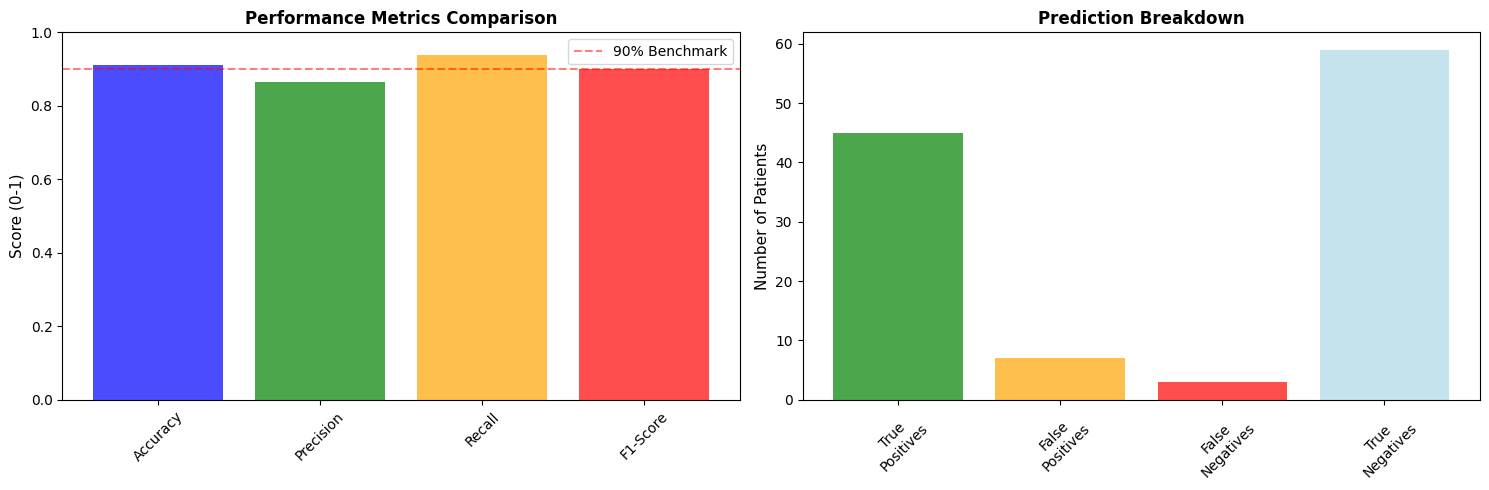

In [136]:
print(""" MEDICAL EVALUATION METRICS EXPLAINED:

Think of Skill Morph as a detective looking for malignant cancer:

1️⃣ ACCURACY = Overall correctness
   → How many total cases did we get right?

2️⃣ PRECISION = When we say "MALIGNANT", how often are we right?
   → Of all "malignant" predictions, how many were actually malignant?
   → High precision = Few false alarms

3️⃣ RECALL  = Of all actual malignant cancer cases, how many did we catch?
   → Did we miss any malignant cancer patients?
   → High recall = We don't miss malignant cancer cases

4️⃣ F1-SCORE = Balance between Precision and Recall
   → Perfect balance between avoiding false alarms and catching all malignant cancers
""")

# Calculate detailed metrics
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)


# Create detailed metrics visualization
plt.figure(figsize=(15, 5))

# Subplot 1: Metrics comparison
plt.subplot(1, 2, 1)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1]
colors = ['blue', 'green', 'orange', 'red']
bars = plt.bar(metrics, values, color=colors, alpha=0.7)
plt.ylim(0, 1)
plt.title('Performance Metrics Comparison', fontweight='bold', fontsize=12)
plt.ylabel('Score (0-1)', fontsize=11)


# Add benchmark line
plt.axhline(y=0.9, color='red', linestyle='--', alpha=0.5, label='90% Benchmark')
plt.legend()
plt.xticks(rotation=45)



# Subplot 2: Precision vs Recall visualization
plt.subplot(1, 2, 2)
# Create a simple precision-recall visualization
categories = ['True\nPositives', 'False\nPositives', 'False\nNegatives', 'True\nNegatives']
tp, fp, fn, tn = cm[1,1], cm[0,1], cm[1,0], cm[0,0]
counts = [tp, fp, fn, tn]
colors_pr = ['green', 'orange', 'red', 'lightblue']
bars_pr = plt.bar(categories, counts, color=colors_pr, alpha=0.7)
plt.title('Prediction Breakdown', fontweight='bold', fontsize=12)
plt.ylabel('Number of Patients', fontsize=11)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ROC CURVE & AUC - ADVANCED EVALUATION


 STEP 9: ROC Curve & AUC - The Ultimate Evaluation

ROC CURVE & AUC EXPLAINED:

ROC = Receiver Operating Characteristic
AUC = Area Under Curve


OUR SKILL MORPH DOCTOR AUC SCORE:
AUC Score: 0.9228 (92.28%)


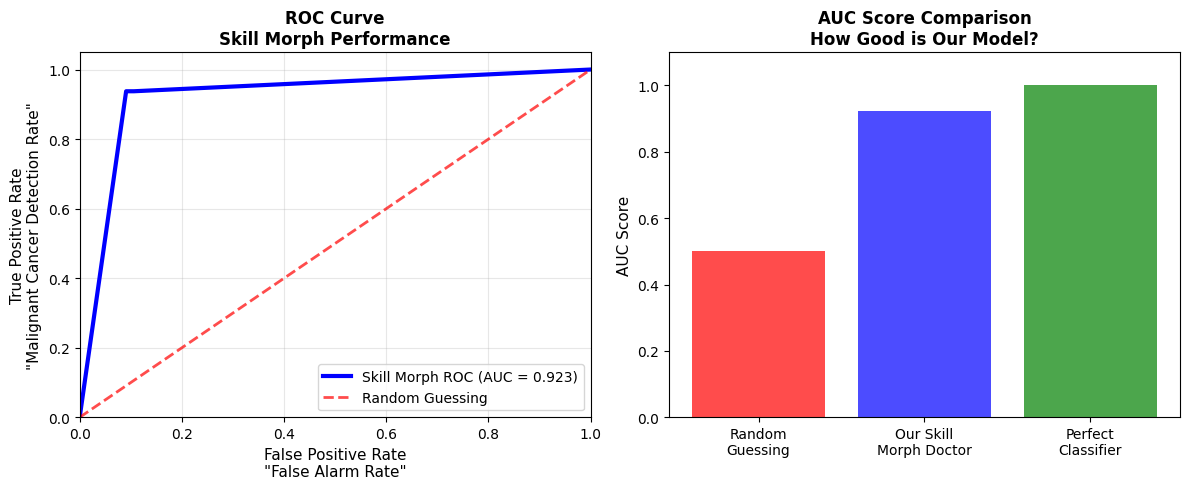

In [137]:
print("\n STEP 9: ROC Curve & AUC - The Ultimate Evaluation")
print("=" * 60)

print("""
ROC CURVE & AUC EXPLAINED:

ROC = Receiver Operating Characteristic
AUC = Area Under Curve

""")

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, prediction_probabilities)
auc_score = roc_auc_score(y_test, prediction_probabilities)

print(f"OUR SKILL MORPH DOCTOR AUC SCORE:")
print(f"{'='*40}")
print(f"AUC Score: {auc_score:.4f} ({auc_score*100:.2f}%)")

# Create comprehensive ROC visualization
plt.figure(figsize=(12, 5))

# Subplot 1: ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='blue', lw=3, label=f'Skill Morph ROC (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', alpha=0.7, label='Random Guessing')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate\n"False Alarm Rate"', fontsize=11)
plt.ylabel('True Positive Rate\n"Malignant Cancer Detection Rate"', fontsize=11)
plt.title('ROC Curve\nSkill Morph Performance', fontweight='bold', fontsize=12)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Subplot 2: AUC Comparison
plt.subplot(1, 2, 2)
model_names = ['Random\nGuessing', 'Our Skill\nMorph Doctor', 'Perfect\nClassifier']
auc_scores = [0.5, auc_score, 1.0]
colors_auc = ['red', 'blue', 'green']
bars_auc = plt.bar(model_names, auc_scores, color=colors_auc, alpha=0.7)

plt.ylim(0, 1.1)
plt.ylabel('AUC Score', fontsize=11)
plt.title('AUC Score Comparison\nHow Good is Our Model?', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()


Assignment